## Импорты и настройки

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.dpi'] = 200

## Загрузка данных

In [2]:
pretrain1_df = pd.read_parquet('../datasets/pretrain_part_1.parquet')
pretrain2_df = pd.read_parquet('../datasets/pretrain_part_2.parquet')
pretrain3_df = pd.read_parquet('../datasets/pretrain_part_3.parquet')

train1_df = pd.read_parquet('../datasets/train_part_1.parquet')
train2_df = pd.read_parquet('../datasets/train_part_2.parquet')
train3_df = pd.read_parquet('../datasets/train_part_3.parquet')

pretest_df = pd.read_parquet('../datasets/pretest.parquet')
test_df = pd.read_parquet('../datasets/test.parquet')

In [3]:
print(f"pretrain1_df: {pretrain1_df.shape}")
print(f"pretrain2_df: {pretrain2_df.shape}")
print(f"pretrain3_df: {pretrain3_df.shape}")

print(f"\ntrain1_df: {train1_df.shape}")
print(f"train2_df: {train2_df.shape}")
print(f"train3_df: {train3_df.shape}")

print(f"\npretest_df: {pretest_df.shape}")
print(f"test_df: {test_df.shape}")

pretrain1_df: (30329960, 23)
pretrain2_df: (30237860, 23)
pretrain3_df: (30372137, 23)

train1_df: (28618594, 23)
train2_df: (28558397, 23)
train3_df: (28500849, 23)

pretest_df: (14202075, 23)
test_df: (633683, 23)


## Сравнение датасетов

### Все ли колонки совпадают?

In [6]:
datasets = {
    'pretrain1': pretrain1_df,
    'pretrain2': pretrain2_df,
    'pretrain3': pretrain3_df,
    'train1': train1_df,
    'train2': train2_df,
    'train3': train3_df,
    'pretest': pretest_df,
    'test': test_df
}

base_columns = set(pretrain1_df.columns)

print("Колонки pretrain1_df:\n")
for col in pretrain1_df.columns:
    print(f"- {col}: {pretrain1_df[col].dtype}")

print("\nСравнение с остальными датасетами:\n")

for name, df in datasets.items():
    if name == 'pretrain1':
        continue
    current_columns = set(df.columns)
    if current_columns == base_columns:
        print(f"{name}: колонки совпадают")
    else:
        print(f"{name}: колонки НЕ совпадают")
        missing = base_columns - current_columns
        extra = current_columns - base_columns
        if missing:
            print(f"   Отсутствуют: {missing}")
        if extra:
            print(f"   Лишние: {extra}")

Колонки pretrain1_df:

- customer_id: int64
- event_id: int64
- event_dttm: str
- event_type_nm: int32
- event_desc: int32
- channel_indicator_type: int32
- channel_indicator_sub_type: int32
- operaton_amt: float64
- currency_iso_cd: float64
- mcc_code: str
- pos_cd: float64
- accept_language: str
- browser_language: str
- timezone: float64
- session_id: float64
- operating_system_type: float64
- battery: str
- device_system_version: str
- screen_size: str
- developer_tools: str
- phone_voip_call_state: float64
- web_rdp_connection: float64
- compromised: str

Сравнение с остальными датасетами:

pretrain2: колонки совпадают
pretrain3: колонки совпадают
train1: колонки совпадают
train2: колонки совпадают
train3: колонки совпадают
pretest: колонки совпадают
test: колонки совпадают


### Одинаковый ли список пользователей в множествах pretrain, train, pretest и test?

In [7]:
pretrain_customers = set(pretrain1_df['customer_id']).union(
    pretrain2_df['customer_id'],
    pretrain3_df['customer_id']
)

train_customers = set(train1_df['customer_id']).union(
    train2_df['customer_id'],
    train3_df['customer_id']
)

pretest_customers = set(pretest_df['customer_id'])
test_customers = set(test_df['customer_id'])

print(f"pretrain: {len(pretrain_customers)} уникальных пользователей")
print(f"train: {len(train_customers)} уникальных пользователей")
print(f"pretest: {len(pretest_customers)} уникальных пользователей")
print(f"test: {len(test_customers)} уникальных пользователей")

pretrain_train = pretrain_customers & train_customers
print(f"pretrain ∩ train: {len(pretrain_train)} пользователей")

pretrain_pretest = pretrain_customers & pretest_customers
print(f"\npretrain ∩ pretest: {len(pretrain_pretest)} пользователей")

pretrain_test = pretrain_customers & test_customers
print(f"pretrain ∩ test: {len(pretrain_test)} пользователей")

train_pretest = train_customers & pretest_customers
print(f"\ntrain ∩ pretest: {len(train_pretest)} пользователей")

train_test = train_customers & test_customers
print(f"train ∩ test: {len(train_test)} пользователей")

pretest_test = pretest_customers & test_customers
print(f"\npretest ∩ test: {len(pretest_test)} пользователей")

all_groups = pretrain_customers & train_customers & pretest_customers & test_customers
print(f"\nПользователи во всех 4 группах: {len(all_groups)}")

pretrain: 100000 уникальных пользователей
train: 100000 уникальных пользователей
pretest: 96953 уникальных пользователей
test: 94241 уникальных пользователей
pretrain ∩ train: 100000 пользователей

pretrain ∩ pretest: 96953 пользователей
pretrain ∩ test: 94241 пользователей

train ∩ pretest: 96953 пользователей
train ∩ test: 94241 пользователей

pretest ∩ test: 91643 пользователей

Пользователи во всех 4 группах: 91643


**Вывод:** во всех сетах примерно одни и те же пользователи. Только в test появляется примерно 3% ранее неизвестных пользователей.

### Как распределяются суммы операций по сетам?

In [8]:
groups = {
    'pretrain': pd.concat([pretrain1_df, pretrain2_df, pretrain3_df]),
    'train': pd.concat([train1_df, train2_df, train3_df]),
    'pretest': pretest_df,
    'test': test_df
}

print(f"{'Сет':<10} {'Среднее':>12} {'Медиана':>12} {'Min':>12} {'Max':>12} {'Std':>10} {'Пропуски %':>13}")

for name, df in groups.items():
    amt = df['operaton_amt']
    missing_pct = amt.isna().mean() * 100
    print(f"{name:<10} {amt.mean():>12.0f} {amt.median():>12.0f} "
          f"{amt.min():>12.0f} {amt.max():>12.0f} {amt.std():>12.0f} {missing_pct:>9.2f}%")

Сет             Среднее      Медиана          Min          Max        Std    Пропуски %
pretrain        1558171        60554            0 651430007184    154138569     41.59%
train           2330582        70746            0 343964253166    207836393     46.48%
pretest         1786552        69370            0 118778306698    100866247     49.34%
test            2328312        83731            0  45412091781     89089822     53.73%


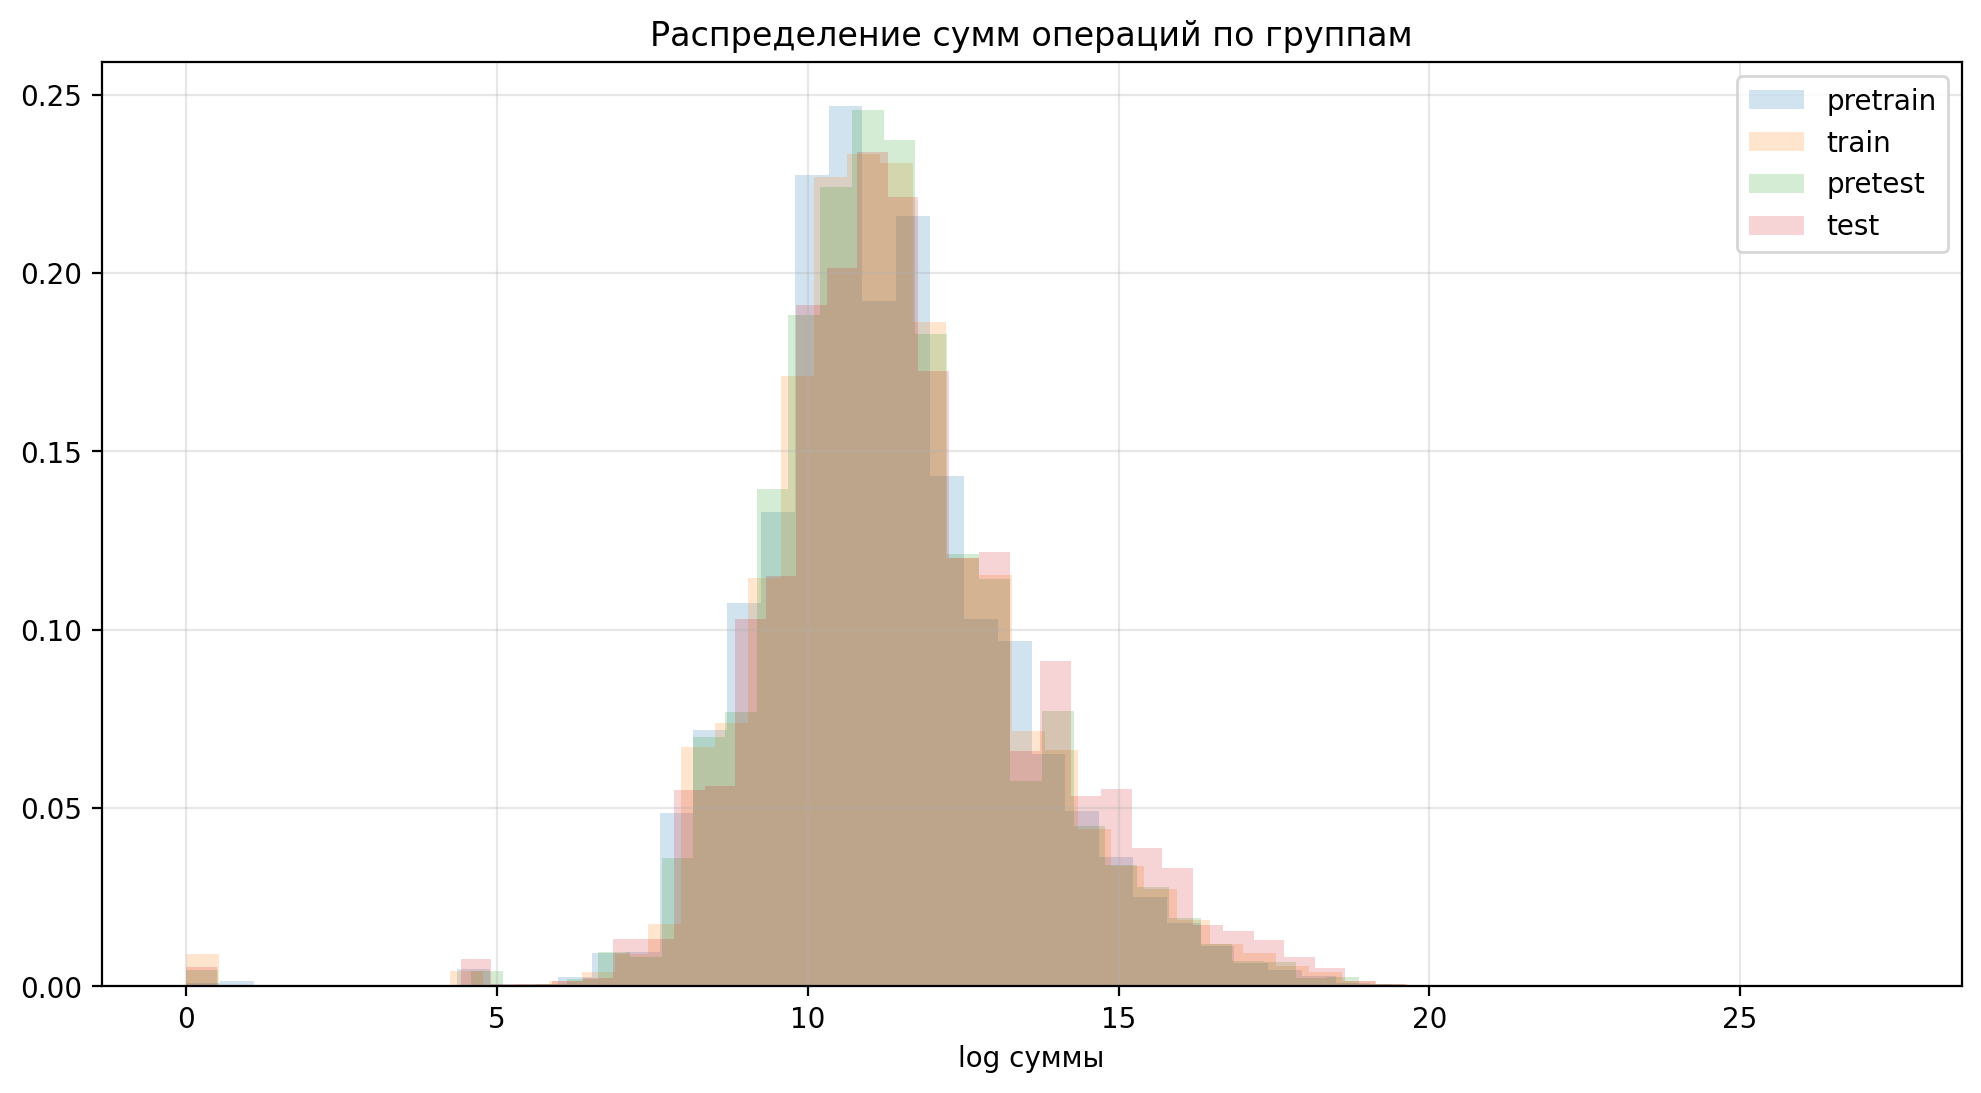

In [9]:
plt.figure(figsize=(12, 6))

for name, df in groups.items():
    log_amt = np.log1p(df['operaton_amt'].dropna())
    plt.hist(log_amt, bins=50, alpha=0.2, label=name, density=True)

plt.xlabel('log суммы')
plt.title('Распределение сумм операций по группам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Выводы:**
* распределение сумм в целом сходно
* в test менее экстремальные большие суммы, но медиана больше (на 15% больше, чем в train)
* в test больше пропусков (на 7% больше, чем в train)

### Сходно ли количество пропусков в колонках каждого из сетов?

In [10]:
print(f"{'Колонка':<25}", end='')
for name in groups.keys():
    print(f"{name:>10}", end='')
print()

for col in groups['train'].columns:
    print(f"{col:<25}", end='')
    for name, df in groups.items():
        missing_pct = df[col].isna().mean() * 100
        print(f"{missing_pct:>9.2f}%", end='')
    print()

Колонка                    pretrain     train   pretest      test
customer_id                   0.00%     0.00%     0.00%     0.00%
event_id                      0.00%     0.00%     0.00%     0.00%
event_dttm                    0.00%     0.00%     0.00%     0.00%
event_type_nm                 0.00%     0.00%     0.00%     0.00%
event_desc                    0.00%     0.00%     0.00%     0.00%
channel_indicator_type        0.00%     0.00%     0.00%     0.00%
channel_indicator_sub_type     0.00%     0.00%     0.00%     0.00%
operaton_amt                 41.59%    46.48%    49.34%    53.73%
currency_iso_cd              39.78%    45.22%    48.27%    52.43%
mcc_code                     64.95%    71.26%    72.28%    75.66%
pos_cd                       66.45%    91.30%    93.63%    93.34%
accept_language              83.80%    88.95%    89.95%    89.98%
browser_language            100.00%    90.82%    91.70%    91.49%
timezone                     84.99%    90.47%    91.62%    91.39%
session_i

**Выводы:** 
* в pretest многие колонки _не заполнены_
* в pretest и test количество пропусков сходно train
* в "важных" колонках, которые полностью заполнены в train, в остальных сетах также _нет пропусков_

### Совпадают ли MCC-коды?

Некоторые значения MCC-кодов (вид деятельности торговой точки) являются "подозрительными" в train - среди них повышено количество фрода.  
Посмотрим их распределение в остальных сетах.

In [11]:
for name, df in groups.items():
    mcc_vals = df['mcc_code'].dropna().unique()
    missing_pct = df['mcc_code'].isna().mean() * 100
    print(f"{name}: {len(mcc_vals)} уникальных MCC, пропусков {missing_pct:.2f}%")

train_mcc = set(groups['train']['mcc_code'].dropna().unique())
test_mcc = set(groups['test']['mcc_code'].dropna().unique())
new_in_test = test_mcc - train_mcc

print(f"\nMCC в test, которых нет в train: {len(new_in_test)}")
if len(new_in_test) > 0:
    print(f"Новые коды: {sorted(new_in_test)}")

pretrain: 20 уникальных MCC, пропусков 64.95%
train: 20 уникальных MCC, пропусков 71.26%
pretest: 20 уникальных MCC, пропусков 72.28%
test: 20 уникальных MCC, пропусков 75.66%

MCC в test, которых нет в train: 0


**Вывод:** во всех сетах используются одинаковые MCC-коды, отличий нет.

### Совпадают ли валюты?

In [12]:
for name, df in groups.items():
    curr_vals = df['currency_iso_cd'].dropna().unique()
    missing_pct = df['currency_iso_cd'].isna().mean() * 100
    print(f"{name}: {len(curr_vals)} валют, пропусков {missing_pct:.2f}%")

train_curr = set(groups['train']['currency_iso_cd'].dropna().unique())
test_curr = set(groups['test']['currency_iso_cd'].dropna().unique())
new_curr = test_curr - train_curr

print(f"Валюты в test, которых нет в train: {new_curr if new_curr else 0}")

pretrain: 24 валют, пропусков 39.78%
train: 23 валют, пропусков 45.22%
pretest: 16 валют, пропусков 48.27%
test: 9 валют, пропусков 52.43%
Валюты в test, которых нет в train: 0


**Вывод:** в тестовых сетах набор валют отличается от тренировочных, но их набор _меньше_, новых уникальных значений нет, это не должно повлиять на качество предсказаний.